In [1]:
# IMPORT DATA FROM GOOGLE DRIVE FOLDER (OPTIONAL)
# https://drive.google.com/file/d/1KquMbMWFK_2x02Hlvz8FCecuzcAwFCGy/view?usp=sharing # tif delta clipped
!gdown --id 1KquMbMWFK_2x02Hlvz8FCecuzcAwFCGy

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1KquMbMWFK_2x02Hlvz8FCecuzcAwFCGy
To: /content/delta_1-7_bbox.tif
100% 5.27M/5.27M [00:00<00:00, 28.6MB/s]


In [2]:
# INSTALL LIBRARIES AND DEPENDENCIES
import geopandas as gpd
!pip install rasterio
import rasterio
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# OPEN L8 SCENE IN RASTER FILE
tif_path = f'/content/delta_1-7_bbox.tif' # dn image
tif = rasterio.open(tif_path)

In [5]:
# OPEN AND EXTRACT BANDS DATA FROM IMAGE, AND STORE IN AN 3D NUMPY ARRAY
listBands_dn = []

with rasterio.open(tif_path) as src:

  profile = src.profile.copy()

  for b in range(1, tif.read().shape[0]+1):
      listBands_dn.append(src.read(b))

arrayBands_dn = np.array(listBands_dn)

(array([6.73000e+02, 0.00000e+00, 0.00000e+00, 1.00000e+00, 1.87150e+04,
        1.51683e+05, 1.56850e+04, 1.22000e+03, 6.00000e+00, 1.00000e+00]),
 array([    0.,  1671.,  3342.,  5013.,  6684.,  8355., 10026., 11697.,
        13368., 15039., 16710.]),
 <BarContainer object of 10 artists>)

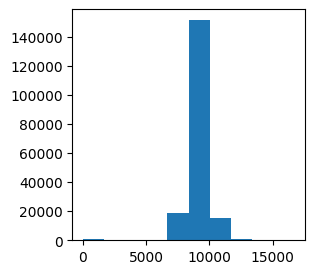

In [7]:
# VISUALIZE BAND 1 (IDX: 0) HISTOGRAM
fig, ax = plt.subplots(figsize=(3, 3))
ax.hist(arrayBands_dn[0].flatten())

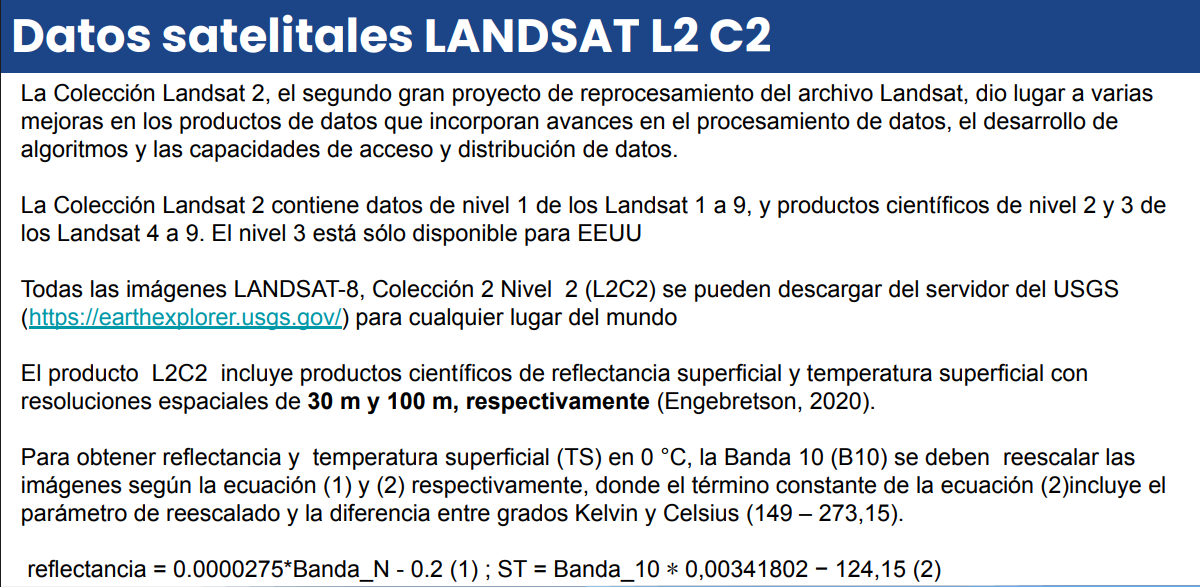

In [8]:
# CONVERT DN DATA TO REFLECTANCE ACCORDING TO L8 SPECIFICATIONS
arrayBands_ref = (0.0000275*arrayBands_dn- 0.2)
arrayBands_ref = np.where(arrayBands_ref < 0, np.nan, arrayBands_ref)

(array([9.2310e+03, 1.2764e+05, 3.6515e+04, 1.2016e+04, 9.4000e+02,
        9.4800e+02, 1.0000e+01, 2.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([0.000475  , 0.02638001, 0.05228501, 0.07819001, 0.10409501,
        0.13000001, 0.15590502, 0.18181002, 0.20771502, 0.23362002,
        0.259525  ]),
 <BarContainer object of 10 artists>)

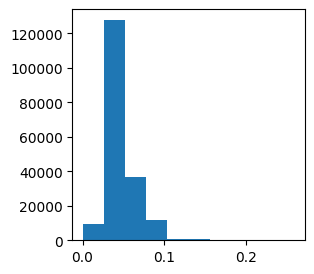

In [9]:
# VISUALIZE AND CHECK CONVERSION FROM DN TO REFLECTANCE
fig, ax = plt.subplots(figsize=(3, 3))
ax.hist(arrayBands_ref[0].flatten())

In [11]:
# CALCULATE INDICES
# NOTE: you can add any other index as needed. just extract bands, compute and concatenate the new bands

## NDVI

# extract red and nir bands
red_ref = arrayBands_ref[3]
nir_ref = arrayBands_ref[5]

# compute ndvi and concatenate to the original 3d array
ndvi = (nir_ref-red_ref)/(nir_ref+red_ref)
arrayBands_ref = np.concatenate((arrayBands_ref, ndvi[np.newaxis, :, :]), axis=0)

## NDWI

# extract red and nir bands
green_ref = arrayBands_ref[2]
nir_ref = arrayBands_ref[5]

# compute ndwi and concatenate to the original 3d array
ndwi = (green_ref-nir_ref)/(green_ref+nir_ref)
arrayBands_ref = np.concatenate((arrayBands_ref, ndwi[np.newaxis, :, :]), axis=0)

(array([39725., 48953., 36511., 26013., 17575., 15078.,  1885.,   338.,
          556.,   674.]),
 array([0.00129999, 0.05763099, 0.11396199, 0.17029299, 0.226624  ,
        0.28295499, 0.33928597, 0.39561701, 0.45194799, 0.50827897,
        0.56461   ]),
 <BarContainer object of 10 artists>)

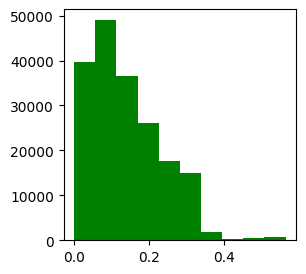

In [10]:
# VISUALIZE NDVI BAND DISTRIBUTION
fig, ax = plt.subplots(figsize=(3, 3))
ax.hist(arrayBands_ref[-1].flatten(), color="green")

In [13]:
# UPDATE THE EXTRACTED ORIGINAL RASTER PROFILE, AND THEN SAVE THE GENERATED TIF WITH n + t BANDS

# Define output file name
outfile = 'stack_1-7&indices.tif'

# Update profile
profile.update(
    tiled=True,
    blockxsize=256,  # Ensure blockxsize is a multiple of 16
    blockysize=256,  # Ensure blockysize is a multiple of 16
    count = arrayBands_ref.shape[0],   # Use the correct number of bands after concatenation
)

# Write the output with the NDVI band
with rasterio.open(outfile, "w", **profile) as dst:
    # write original bands
    for i in range(arrayBands_ref.shape[0]):
        dst.write(arrayBands_ref[i], i + 1)